In [ ]:
from src.constants import PROCESSED_DATA_PATH
from src.utils import hd_tuning, circ_colors, plot_tuning_grid, plot_intervals, find_outliers

import numpy as np
import pandas as pd
import pynapple as nap
import seaborn as sns
import matplotlib.colors as mcolors
import umap
import umap.plot
import xarray as xr

from matplotlib import pyplot as plt
from scipy.io import loadmat
from scipy.signal.windows import gaussian

import pynaviz as viz
from pynaviz import scope

# === CONFIG ===
unit_id = "116b"
WAKE_BIN = 0.1
NREM_BIN = 0.05
SMOOTH_STD = 0.2
SMOOTH_WIN = 2
UMAP_NEIGHBORS = 200
UMAP_MIN_DIST = 0.2

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.5, rc=custom_params)
# === FUNCTION DEFINITIONS ===

def prep_rates(spikes, epochs, bin_size=WAKE_BIN, std=SMOOTH_STD, win=SMOOTH_WIN):
    """Bin, smooth, and sqrt-transform spike counts."""
    binned = spikes.count(bin_size=bin_size, ep=epochs)
    return np.sqrt(binned.smooth(std=std, windowsize=win))

def fit_umap(data, n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST, metric='cosine'):
    """Fit UMAP reducer."""
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=2, metric=metric)
    reducer.fit(data)
    return reducer

prj = nap.load_folder(PROCESSED_DATA_PATH.parent)
prj.view

c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\iii9781\nrem_sc\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)


### Load

In [ ]:
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")
sessions        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")

### Visualize the events

(<Figure size 1400x250 with 1 Axes>, <Axes: xlabel='Time (s)'>)

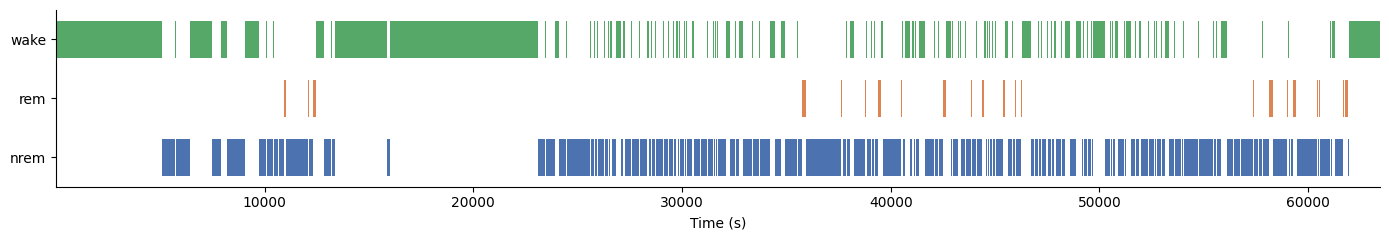

In [3]:
plot_intervals(sleep_states, column='state')

(<Figure size 1400x250 with 1 Axes>, <Axes: xlabel='Time (s)'>)

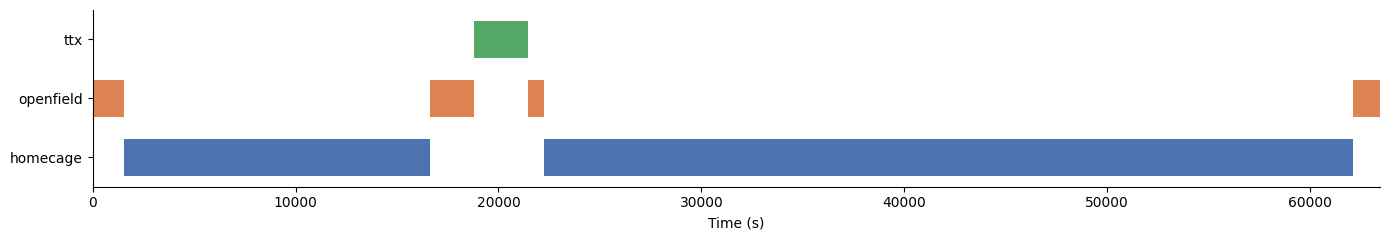

In [4]:
plot_intervals(sessions, column='label')

### Tuning curves

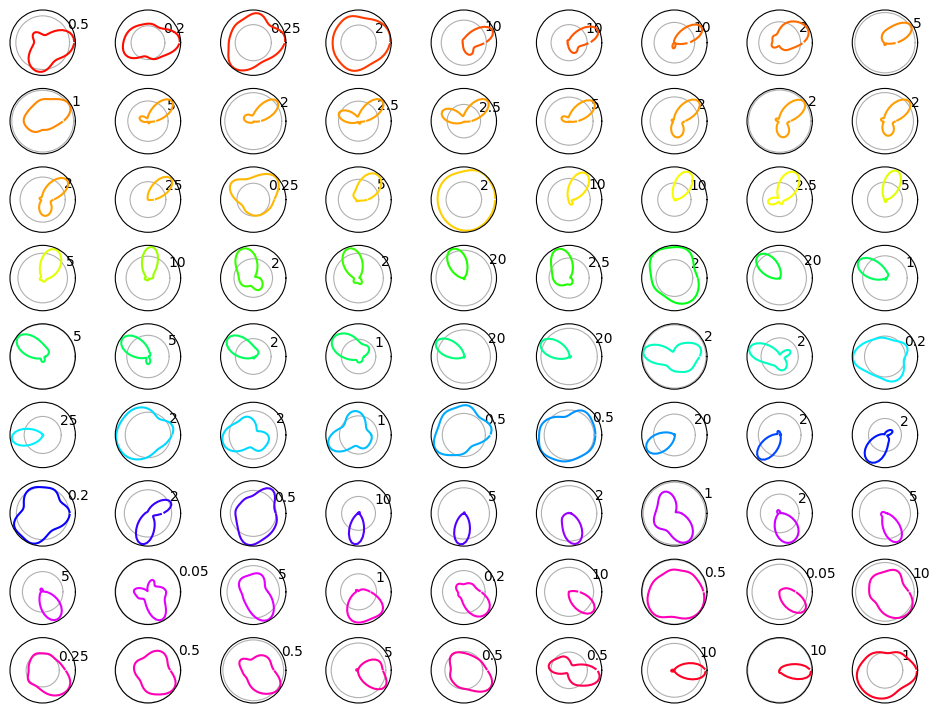

In [5]:
tcs, pref_ang = hd_tuning(hd_spikes, hd_angle)
color = xr.DataArray(circ_colors(pref_ang.values), dims=("unit", "color"), coords={"unit": pref_ang.unit})
_ = plot_tuning_grid(tcs, pref_ang, color)

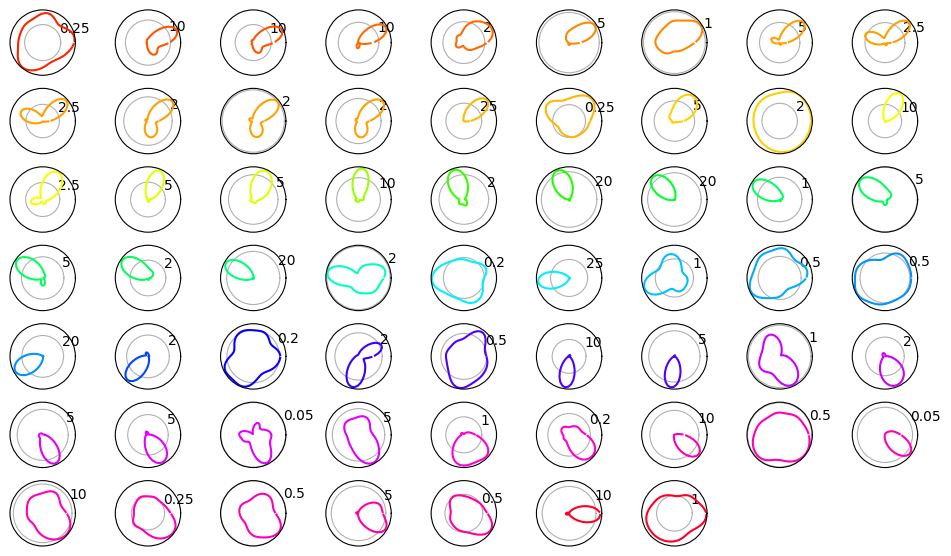

In [6]:
# Filter HD cells for narrow tuning based on kappa
hd_spikes_filt = hd_spikes[hd_spikes['kappa'] > 2.5]
hd_spikes_filt = hd_spikes_filt[hd_spikes_filt['kappa'] < 10]

tcs, pref_ang = hd_tuning(hd_spikes_filt, hd_angle)
color = xr.DataArray(circ_colors(pref_ang.values), dims=("unit", "color"), coords={"unit": pref_ang.unit})
_ = plot_tuning_grid(tcs, pref_ang, color)

In [7]:
hd_spikes = hd_spikes_filt

### Wake manifold

Preprocessing

In [9]:
epochs = hd_angle.time_support
hd_angle = hd_angle.bin_average(bin_size=WAKE_BIN, ep=epochs)
wake_rate = prep_rates(hd_spikes, epochs)

print(f"wake_rate shape: {wake_rate.shape}")

wake_rate shape: (21095, 61)


<Axes: >

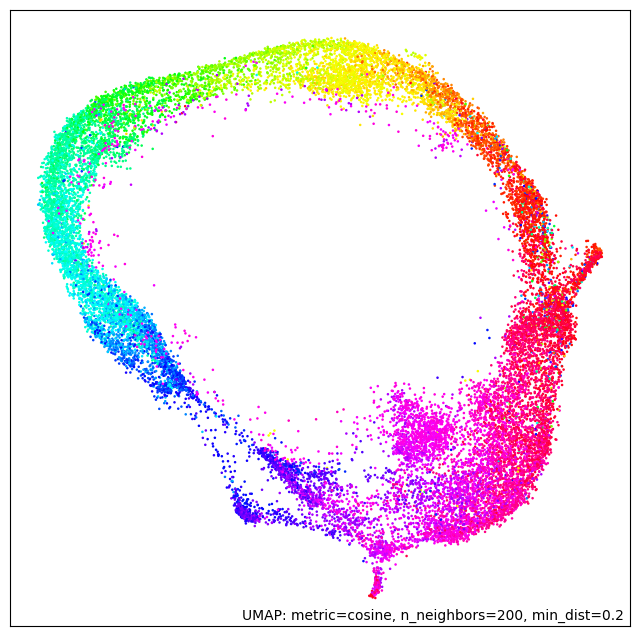

In [10]:
reducer = fit_umap(wake_rate)
wake_embds = reducer.embedding_
umap.plot.points(reducer, values=hd_angle.values, cmap='hsv')

### NREM projection

In [11]:
epochs = sessions[sessions['label'] == 'homecage'][0]

bin_size = 0.05
std = 0.1
win = 1

binned = hd_spikes.count(bin_size=bin_size, ep=epochs)
smooth_rate = np.sqrt(binned.smooth(std=std, windowsize=win))
print(f"smooth_rate shape: {smooth_rate.shape}")

smooth_rate shape: (301863, 61)


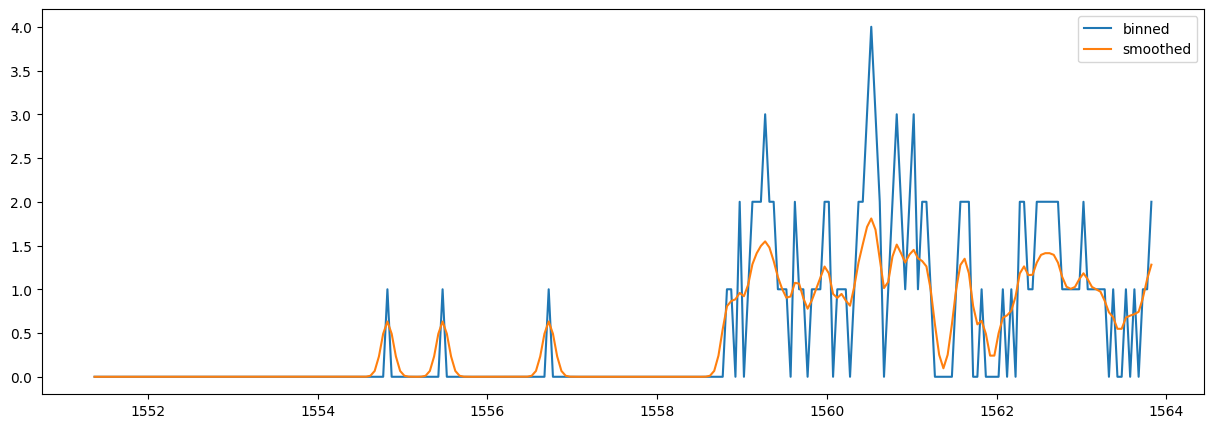

In [271]:
t_a, t_b = 0, 250
channel = 7

plt.figure(figsize=(15, 5))
plt.plot(binned[t_a:t_b, channel])
plt.plot(smooth_rate[t_a:t_b, channel])
plt.legend(['binned', 'smoothed'])

In [12]:
sleep_embds = reducer.transform(smooth_rate)
manifold = nap.TsdFrame(t=smooth_rate.t, d=sleep_embds, columns=['x', 'y'])

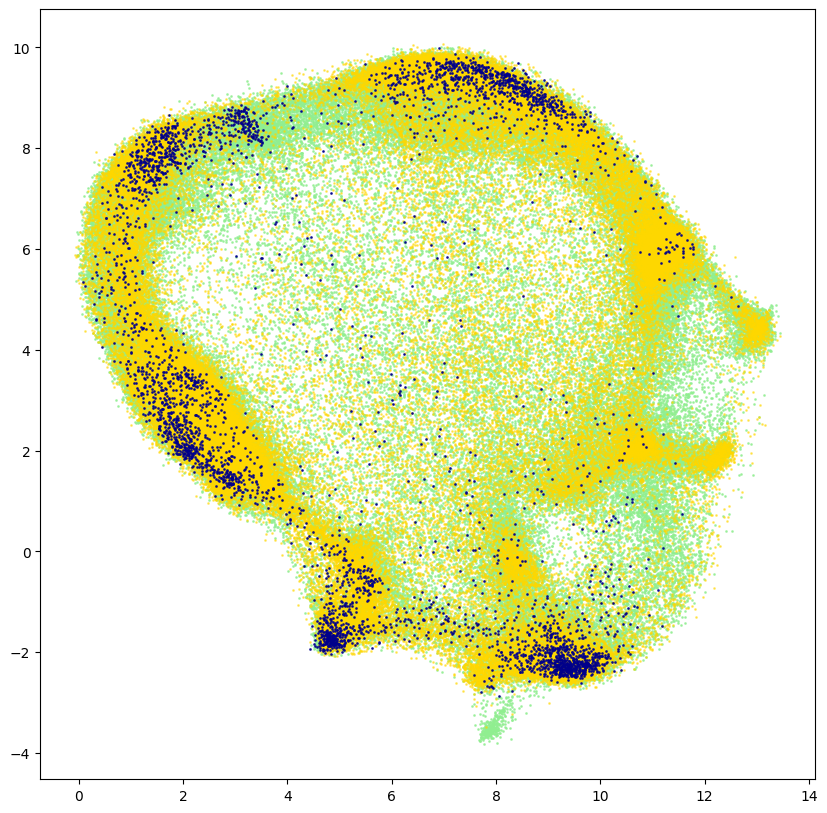

In [14]:
fig, ax = plt.subplots(figsize=(10, 10))
# ax.scatter(wake_embds[:, 0], wake_embds[:, 1], c=hd_angle.values, cmap='hsv', s=3)
ax.scatter( x = manifold.restrict(sleep_states[sleep_states['state'] == 'wake'])[:, 0], 
            y = manifold.restrict(sleep_states[sleep_states['state'] == 'wake'])[:, 1],
            c='lightgreen', s=1, alpha=0.7)


ax.scatter( x = manifold.restrict(sleep_states[sleep_states['state'] == 'nrem'])[:, 0], 
            y = manifold.restrict(sleep_states[sleep_states['state'] == 'nrem'])[:, 1],
            c='gold', s=1, alpha=0.5)

ax.scatter( x = manifold.restrict(sleep_states[sleep_states['state'] == 'rem'])[:, 0], 
            y = manifold.restrict(sleep_states[sleep_states['state'] == 'rem'])[:, 1],
            c='darkblue', s=1, alpha=0.8)


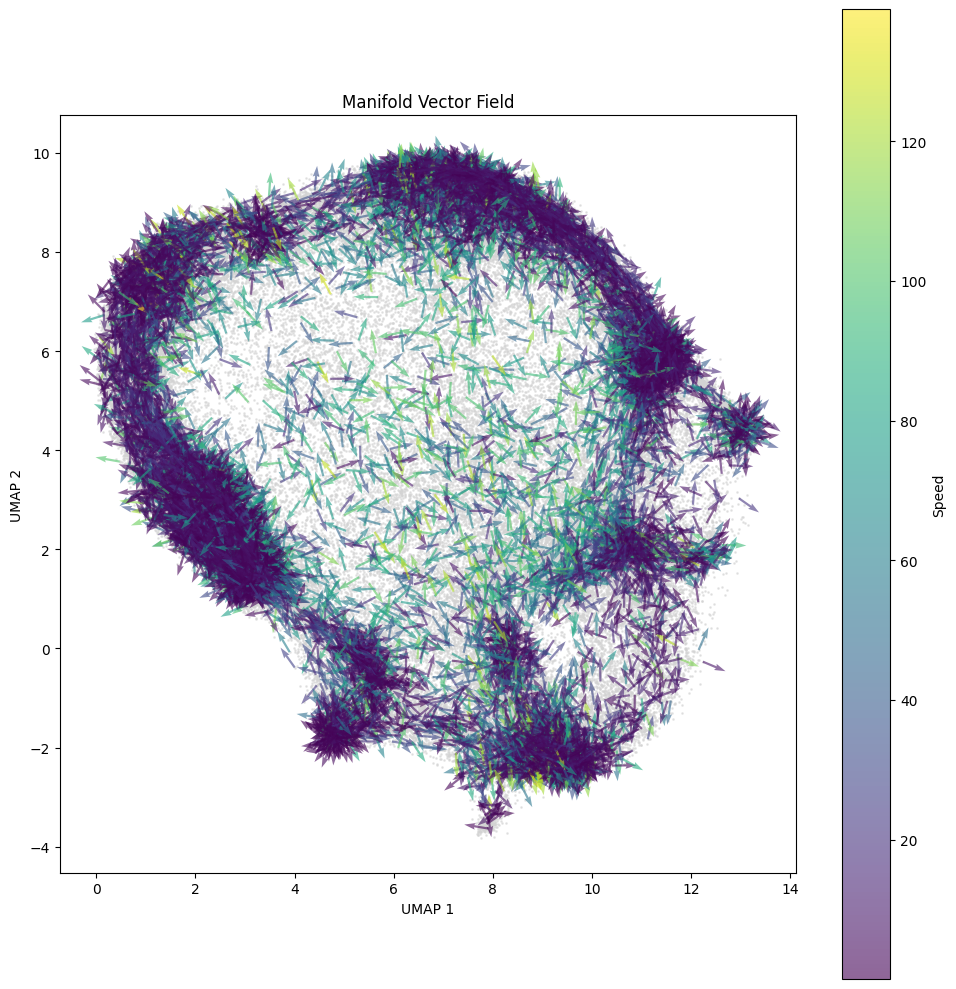

In [16]:
data = manifold
    
# Compute velocity vectors using pynapple's derivative method
velocity = data.derivative()
vx = velocity['x'].values
vy = velocity['y'].values

# Compute speed (magnitude)
speed = np.sqrt(vx**2 + vy**2)

# Normalize vectors to unit length
vx_norm = vx / (speed + 1e-10)
vy_norm = vy / (speed + 1e-10)

# Get positions at velocity timestamps (derivative uses midpoints)
x_pos = data['x'].restrict(velocity.time_support).values
y_pos = data['y'].restrict(velocity.time_support).values

# Subsample for clearer visualization (every nth point)
step = 25  # adjust for density of arrows

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the trajectory as faint background
ax.scatter(data['x'].values, data['y'].values, c='lightgray', s=1, alpha=0.5)

# Plot normalized velocity vectors
q = ax.quiver(x_pos[::step], y_pos[::step],
              vx_norm[::step], vy_norm[::step],
              speed[::step],  # color by speed
              cmap='viridis', alpha=0.6,
              scale=30,
              width=0.003)

plt.colorbar(q, label='Speed')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('Manifold Vector Field')
ax.set_aspect('equal')
plt.tight_layout()

### Viz

In [ ]:
scope({'sleep': sleep_states, 'units': hd_spikes, 'manifold': manifold})